In [19]:
%pip install pandas numpy matplotlib seaborn scikit-learn pyarrow


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Camada ML — Clusterização K-Means



In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from math import pi

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

GOLD_DIR = Path("../gold")
CLUSTER_DIR = Path("../clustering")
CLUSTER_DIR.mkdir(parents=True, exist_ok=True)

## 1. Carregamento dos dados Gold

In [21]:
# Features para o modelo (sem o target)
X = pd.read_parquet(GOLD_DIR / "customer_features.parquet")

# Target separado — será usado só para validação de negócio.
df_ref = pd.read_parquet(GOLD_DIR / "churn_reference.parquet")

print(f"Shape de X: {X.shape}")
print(f"Nulos em X: {X.isnull().sum().sum()}")
print(f"\nPrimeiras linhas:")
X.head(3)

Shape de X: (7032, 27)
Nulos em X: 0

Primeiras linhas:


,gender,SeniorCitizen,is_single_no_dependents,family_size_norm,PhoneService,MultipleLines,internet_service_flag,internet_dsl_flag,internet_fiber_flag,OnlineSecurity,...,service_count_norm,is_month_to_month,contract_term_months_norm,PaperlessBilling,payment_automatic,payment_electronic_check,tenure_norm,MonthlyCharges_norm,TotalCharges_norm,charges_per_month_ratio_norm
0,0,0,0,0.5,0,0,1,1,0,0,...,0.125,1,0.000000,1,0,1,0.000000,0.115423,0.001275,0.052298
1,1,0,1,0.0,1,0,1,1,0,1,...,0.375,0,0.478261,0,0,0,0.464789,0.385075,0.215867,0.408086
2,1,0,1,0.0,1,0,1,1,0,1,...,0.375,1,0.000000,1,0,0,0.014085,0.354229,0.010310,0.244717


## 2. Elbow Method — Determinando o K ideal



In [22]:
K_RANGE = range(2, 11)  
inercias = []
silhouette_scores = []
calinski_scores = []
davies_scores = []

for k in K_RANGE:
    km = KMeans(
        n_clusters=k,
        init="k-means++",   
        n_init=10,          
        max_iter=300,
        random_state=RANDOM_STATE
    )
    labels = km.fit_predict(X)
    
    inercias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X, labels, sample_size=2000, random_state=RANDOM_STATE))
    calinski_scores.append(calinski_harabasz_score(X, labels))
    davies_scores.append(davies_bouldin_score(X, labels))
    
    print(f"k={k:2d} | Inércia: {km.inertia_:,.1f} | Silhouette: {silhouette_scores[-1]:.4f} | Calinski: {calinski_scores[-1]:,.1f} | Davies: {davies_scores[-1]:.4f}")

k= 2 | Inércia: 28,222.4 | Silhouette: 0.1851 | Calinski: 1,664.2 | Davies: 2.0389
k= 3 | Inércia: 24,833.5 | Silhouette: 0.1671 | Calinski: 1,425.1 | Davies: 1.9514
k= 4 | Inércia: 22,449.5 | Silhouette: 0.1772 | Calinski: 1,299.6 | Davies: 1.9451
k= 5 | Inércia: 21,094.3 | Silhouette: 0.1699 | Calinski: 1,150.0 | Davies: 2.0501
k= 6 | Inércia: 20,170.0 | Silhouette: 0.1626 | Calinski: 1,026.4 | Davies: 2.1521
k= 7 | Inércia: 19,411.2 | Silhouette: 0.1291 | Calinski: 934.4 | Davies: 2.0814
k= 8 | Inércia: 18,842.3 | Silhouette: 0.1297 | Calinski: 855.3 | Davies: 2.0104
k= 9 | Inércia: 18,436.2 | Silhouette: 0.1327 | Calinski: 784.1 | Davies: 2.2520
k=10 | Inércia: 17,874.5 | Silhouette: 0.1345 | Calinski: 743.3 | Davies: 2.1991


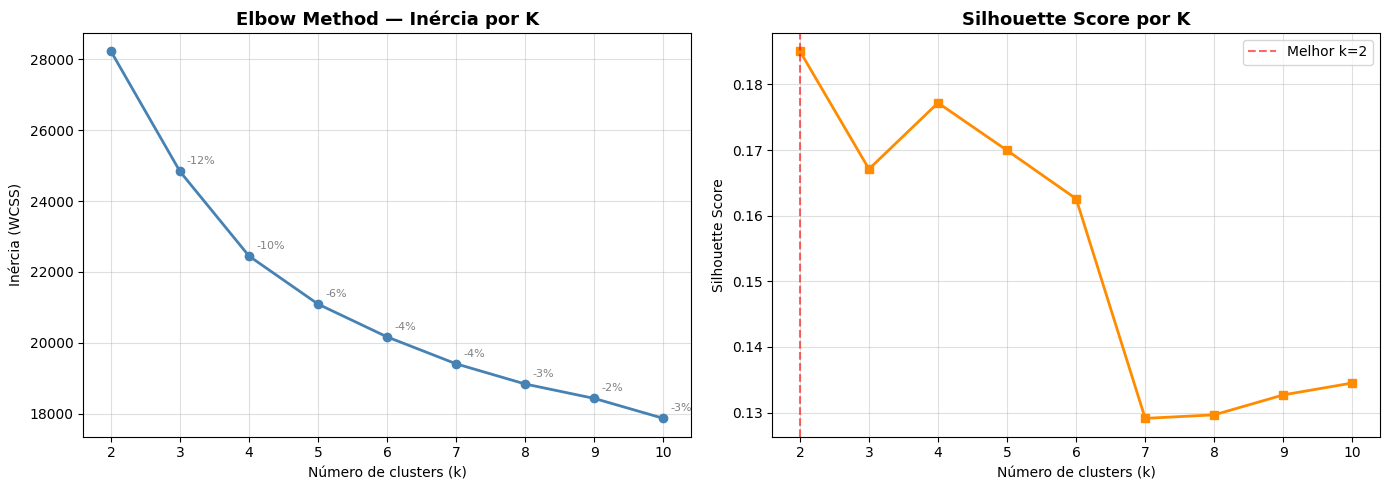


Melhor k pelo Silhouette: 2


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_RANGE), inercias, marker="o", linewidth=2, color="steelblue")
axes[0].set_title("Elbow Method — Inércia por K", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inércia (WCSS)")
axes[0].grid(True, alpha=0.4)
for i, (k, inertia) in enumerate(zip(K_RANGE, inercias)):
    if i > 0:
        delta = (inercias[i-1] - inertia) / inercias[i-1] * 100
        axes[0].annotate(f"-{delta:.0f}%", (k, inertia), textcoords="offset points",
                         xytext=(5, 5), fontsize=8, color="gray")

axes[1].plot(list(K_RANGE), silhouette_scores, marker="s", linewidth=2, color="darkorange")
axes[1].set_title("Silhouette Score por K", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(True, alpha=0.4)

best_k_sil = list(K_RANGE)[np.argmax(silhouette_scores)]
axes[1].axvline(x=best_k_sil, color="red", linestyle="--", alpha=0.6, label=f"Melhor k={best_k_sil}")
axes[1].legend()

plt.tight_layout()
plt.savefig(CLUSTER_DIR / "elbow_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nMelhor k pelo Silhouette: {best_k_sil}")


## 3. Treinamento do K-Means com o K escolhido


In [24]:
K_FINAL = 5

km_final = KMeans(
    n_clusters=K_FINAL,
    init="k-means++",
    n_init=20,          
    max_iter=500,
    random_state=RANDOM_STATE
)

X["cluster"] = km_final.fit_predict(X)

print(f"K-Means treinado com k={K_FINAL}")
print(f"\nDistribuição dos clusters:")
print(X["cluster"].value_counts().sort_index())
print(f"\nProporção por cluster:")
print((X["cluster"].value_counts(normalize=True).sort_index() * 100).round(1).astype(str) + "%")

K-Means treinado com k=5

Distribuição dos clusters:
cluster
0    1206
1    1523
2    1288
3    1130
4    1885
Name: count, dtype: int64

Proporção por cluster:
cluster
0    17.2%
1    21.7%
2    18.3%
3    16.1%
4    26.8%
Name: proportion, dtype: object


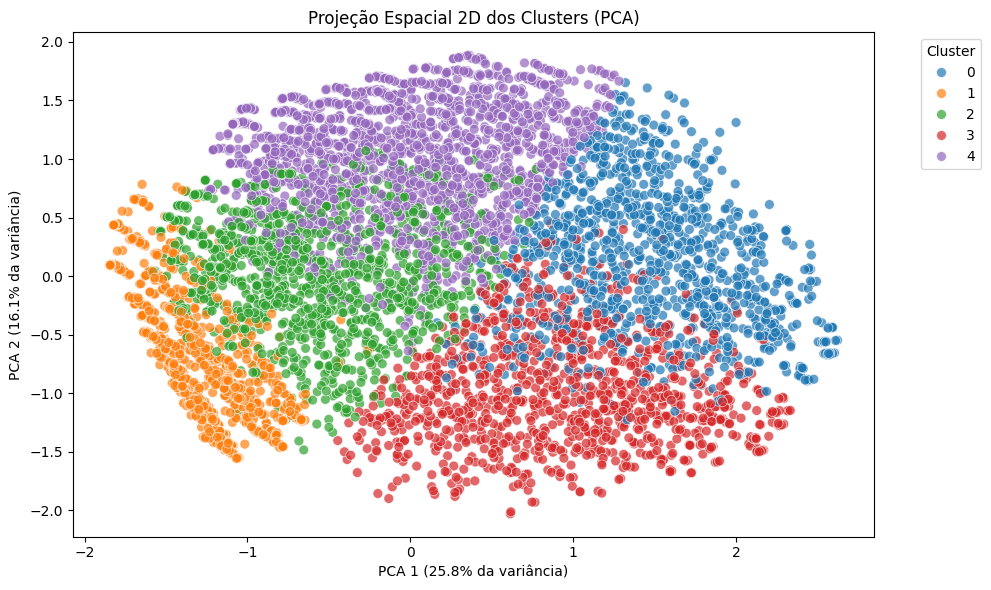

In [25]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X.drop(columns=["cluster"], errors="ignore"))

df_pca = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
df_pca['Cluster'] = X['cluster']

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_pca, x='PCA1', y='PCA2', hue='Cluster', palette='tab10', s=50, alpha=0.7)
plt.title("Projeção Espacial 2D dos Clusters (PCA)")
plt.xlabel(f"PCA 1 ({pca.explained_variance_ratio_[0]:.1%} da variância)")
plt.ylabel(f"PCA 2 ({pca.explained_variance_ratio_[1]:.1%} da variância)")
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(CLUSTER_DIR / "pca_clusters_2d.png")
plt.show()

## 4. Validação Quantitativa dos Clusters



In [26]:
features_only = X.drop(columns=["cluster"])
labels = X["cluster"]

sil = silhouette_score(features_only, labels, sample_size=2000, random_state=RANDOM_STATE)


print("=" * 45)
print(f"  Métricas de validação — k={len(labels.unique())}")
print("=" * 45)
print(f"  Silhouette Score : {sil:.4f}")
print("=" * 45)

  Métricas de validação — k=5
  Silhouette Score : 0.1699


/var/folders/0w/cj1wn0sj19lb7w6cmk5gzfb40000gn/T/ipykernel_26142/1332081369.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.head(10).values, y=importances.head(10).index, palette="viridis")


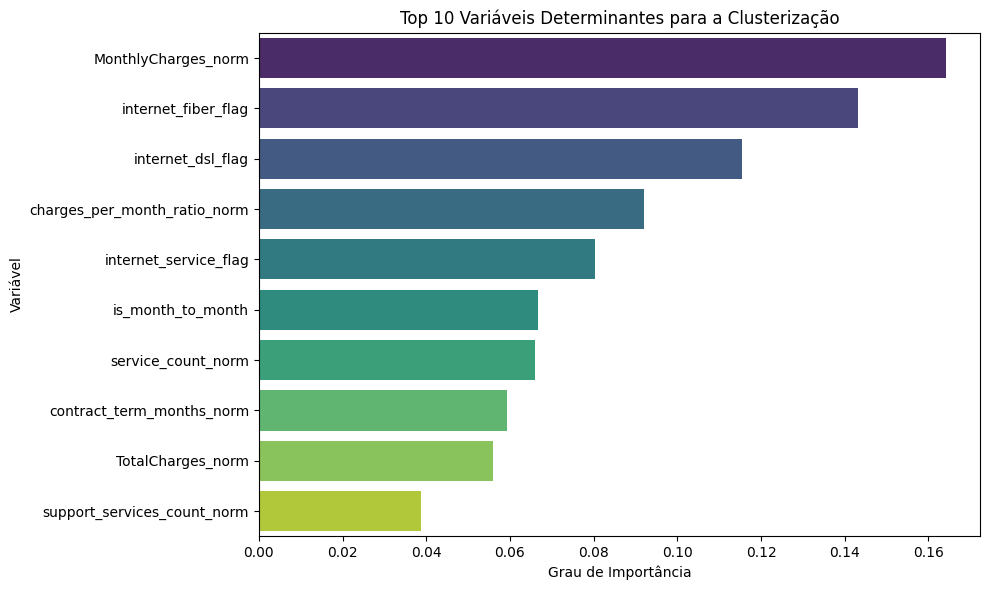

In [27]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
features_only = X.drop(columns=["cluster"])
rf_clf.fit(features_only, X["cluster"])

importances = pd.Series(rf_clf.feature_importances_, index=features_only.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.head(10).values, y=importances.head(10).index, palette="viridis")
plt.title("Top 10 Variáveis Determinantes para a Clusterização")
plt.xlabel("Grau de Importância")
plt.ylabel("Variável")
plt.tight_layout()
plt.savefig(CLUSTER_DIR / "cluster_feature_importance.png")
plt.show()

## 5. Cruzamento com Churn — Validação de Negócio



In [28]:
df_resultado = X[["cluster"]].copy()
df_resultado["Churn"] = df_ref["Churn"].values
df_resultado["customerID"] = df_ref["customerID"].values

churn_por_cluster = df_resultado.groupby("cluster").agg(
    total_clientes=("Churn", "count"),
    total_churn=("Churn", "sum"),
    taxa_churn=("Churn", "mean")
).round(3)

churn_por_cluster["taxa_churn_%"] = (churn_por_cluster["taxa_churn"] * 100).round(1)
print("Taxa de churn por cluster:")
print(churn_por_cluster.to_string())

Taxa de churn por cluster:
         total_clientes  total_churn  taxa_churn  taxa_churn_%
cluster                                                       
0                  1206          245       0.203          20.3
1                  1523          113       0.074           7.4
2                  1288          398       0.309          30.9
3                  1130           61       0.054           5.4
4                  1885         1052       0.558          55.8


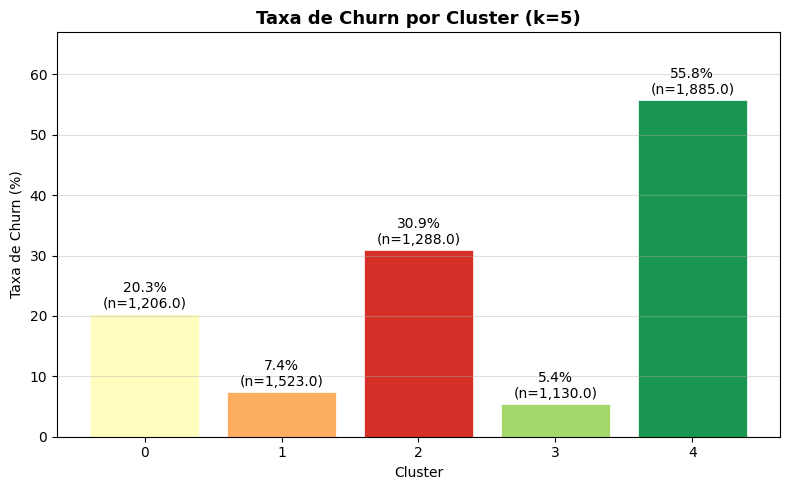

In [29]:
fig, ax = plt.subplots(figsize=(8, 5))
cores = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, 5))
bars = ax.bar(
    churn_por_cluster.index,
    churn_por_cluster["taxa_churn_%"],
    color=sorted(cores, key=lambda c: c[0], reverse=True),  
    edgecolor="white", linewidth=0.5
)
for bar, (_, row) in zip(bars, churn_por_cluster.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{row['taxa_churn_%']}%\n(n={row['total_clientes']:,})",
        ha="center", va="bottom", fontsize=10
    )
ax.set_title(f"Taxa de Churn por Cluster (k={5})", fontsize=13, fontweight="bold")
ax.set_xlabel("Cluster")
ax.set_ylabel("Taxa de Churn (%)")
ax.set_ylim(0, churn_por_cluster["taxa_churn_%"].max() * 1.2)
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig(CLUSTER_DIR / "churn_por_cluster.png", dpi=150, bbox_inches="tight")
plt.show()

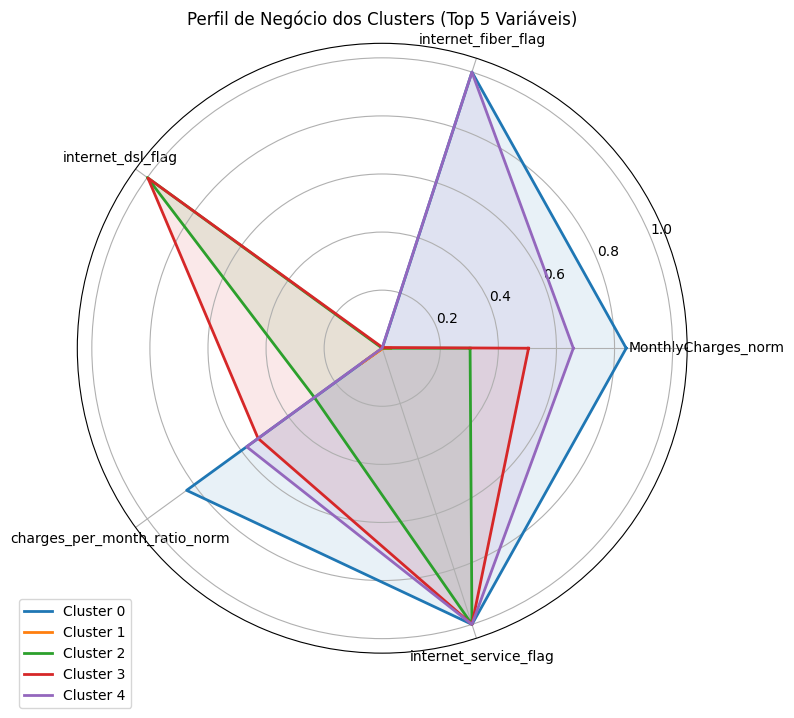

In [30]:
top_features = importances.head(5).index.tolist()
radar_data = X.groupby("cluster")[top_features].mean().reset_index()

categories = top_features
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, row in radar_data.iterrows():
    values = row[categories].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=f"Cluster {int(row['cluster'])}")
    ax.fill(angles, values, alpha=0.1)

plt.xticks(angles[:-1], categories, size=10)
plt.title("Perfil de Negócio dos Clusters (Top 5 Variáveis)")
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.tight_layout()
plt.savefig(CLUSTER_DIR / "cluster_radar_chart.png")
plt.show()

## 6. Perfil dos Clusters — Centróides



In [31]:
FEATURES_PERFIL = [
    "tenure_norm", "MonthlyCharges_norm", "service_count_norm",
    "is_month_to_month", "internet_fiber_flag", "internet_dsl_flag",
    "SeniorCitizen", "is_single_no_dependents",
    "payment_automatic", "payment_electronic_check",
    "support_services_count_norm", "streaming_services_count_norm"
]

perfil = X.groupby("cluster")[FEATURES_PERFIL].mean().round(3)
print("Perfil médio por cluster:")
print(perfil.T.to_string())

Perfil médio por cluster:
cluster                            0      1      2      3      4
tenure_norm                    0.769  0.418  0.216  0.717  0.245
MonthlyCharges_norm            0.840  0.029  0.303  0.504  0.658
service_count_norm             0.737  0.028  0.285  0.655  0.386
is_month_to_month              0.253  0.344  0.884  0.074  0.968
internet_fiber_flag            1.000  0.002  0.000  0.003  0.999
internet_dsl_flag              0.000  0.000  1.000  0.997  0.001
SeniorCitizen                  0.232  0.034  0.125  0.087  0.292
is_single_no_dependents        0.277  0.441  0.639  0.247  0.622
payment_automatic              0.640  0.437  0.285  0.702  0.247
payment_electronic_check       0.309  0.080  0.391  0.127  0.649
support_services_count_norm    0.611  0.000  0.255  0.704  0.192
streaming_services_count_norm  0.829  0.000  0.213  0.612  0.399


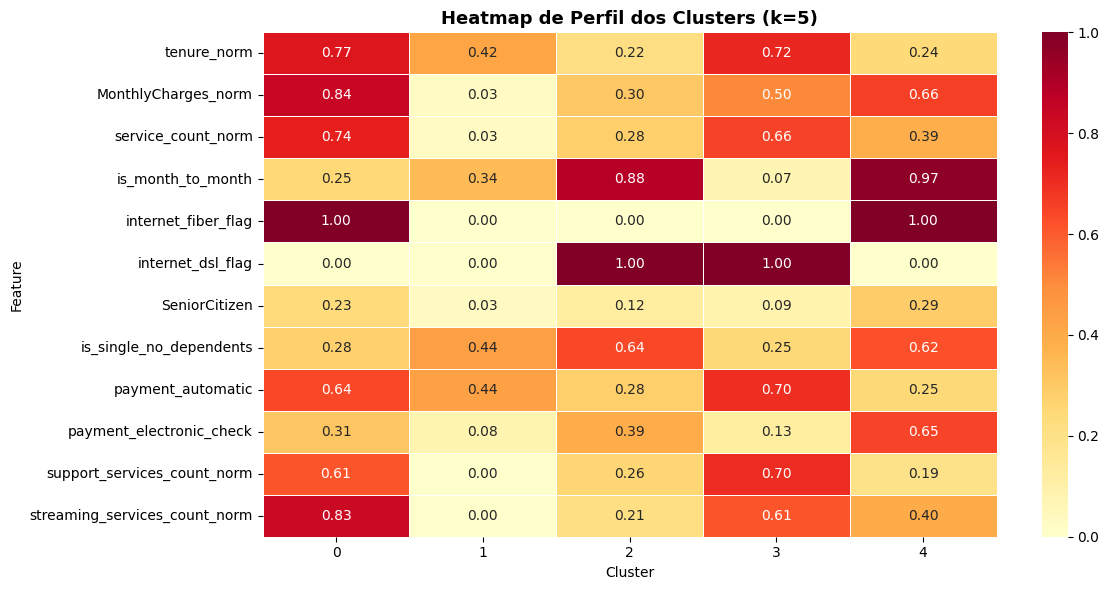

In [32]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    perfil.T,
    annot=True, fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax
)
ax.set_title(f"Heatmap de Perfil dos Clusters (k={5})", fontsize=13, fontweight="bold")
ax.set_xlabel("Cluster")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.savefig(CLUSTER_DIR / "perfil_clusters_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Perguntas/Respostas

**Pergunta 1. Os segmentos de maior churn têm concentração de clientes idosos? Existem necessidades específicas que idosos têm que impactam positiva ou negativamente nas taxas de churn da empresa?**

Sim, os segmentos de maior churn apresentam maior concentração de clientes idosos, mas a idade isoladamente não explica o cancelamento.

O cluster 4 foi o grupo com maior taxa de churn, com **55,8%**, e também apresentou a maior proporção de idosos, com **29,2%** de `SeniorCitizen`. Em contraste, clusters de baixo churn, como o cluster 3 (**5,4%**) e o cluster 1 (**7,4%**), apresentaram proporções bem menores de idosos, de **8,7%** e **3,4%**, respectivamente. Isso indica que existe associação entre presença de idosos e maior churn em alguns segmentos.

Os resultados indicam que o churn é mais impactado pelo perfil de consumo e pelas condições do contrato do que apenas pela idade. No cluster 4, além da concentração de idosos, observaram-se características de maior risco: alta presença de **contrato mensal** (`is_month_to_month = 0.968`), forte presença de **fibra** (`internet_fiber_flag = 0.999`), maior uso de **electronic check** (`payment_electronic_check = 0.649`), **baixo suporte contratado** (`support_services_count_norm = 0.192`) e **baixa permanência** (`tenure_norm = 0.245`).

Isso indica que clientes idosos tendem a ser mais sensíveis a contextos com menor estabilidade, menor suporte e menor vínculo com a empresa. Clusters com churn mais baixo combinam maior permanência mais suporte e contratos menos voláteis. Assim, a principal interpretação é que necessidades de simplicidade, apoio técnico e estabilidade contratual podem impactar positivamente ou negativamente o churn desse público.


In [33]:
# Resultado final: customer_id + cluster + churn (para análise downstream)
df_final = df_resultado.copy()

# Adiciona métricas do cluster
df_final = df_final.merge(churn_por_cluster[["taxa_churn"]], on="cluster", how="left")
df_final.rename(columns={"taxa_churn": "taxa_churn_cluster"}, inplace=True)

df_final.to_parquet(CLUSTER_DIR / "customer_clusters.parquet", index=False, engine="pyarrow")

# Resumo por cluster para relatório
resumo_final = churn_por_cluster.copy()
resumo_final = resumo_final.join(perfil)
resumo_final.to_parquet(CLUSTER_DIR / "cluster_profiles.parquet", engine="pyarrow")

print("Arquivos exportados em ../clustering/:")
for f in sorted(CLUSTER_DIR.iterdir()):
    print(f"  {f.name} ({f.stat().st_size / 1024:.1f} KB)")

print(f"\n{'='*50}")
print(f"RESUMO FINAL — k={5}")
print(f"{'='*50}")
print(f"Silhouette Score : {sil:.4f}")

print(f"\nDistribuição de churn por cluster:")
print(churn_por_cluster[["total_clientes", "taxa_churn_%"]].to_string())

Arquivos exportados em ../clustering/:
  churn_por_cluster.png (43.3 KB)
  cluster_feature_importance.png (34.9 KB)
  cluster_profiles.parquet (12.0 KB)
  cluster_radar_chart.png (140.8 KB)
  customer_clusters.parquet (97.5 KB)
  elbow_silhouette.png (96.2 KB)
  pca_clusters_2d.png (496.4 KB)
  perfil_clusters_heatmap.png (127.0 KB)

RESUMO FINAL — k=5
Silhouette Score : 0.1699

Distribuição de churn por cluster:
         total_clientes  taxa_churn_%
cluster                              
0                  1206          20.3
1                  1523           7.4
2                  1288          30.9
3                  1130           5.4
4                  1885          55.8


**Pergunta 2. Ter cônjuge e/ou dependentes concentra clientes em segmentos de menor churn?**

Sim. Ter família (cônjuge e/ou dependentes) implica diretamente são segmentos notoriamente com a menor taxa de churn. O cluster 3, que possui a menor taxa de churn tem 75.3% de seus clientes com família. O cluster 0, que é o terceiro com menor taxa de churn, possui 72.3% de clientes com família. A correlação encontrada entre clientes com família e taxa de churn também foi significativa. Chegando a -0,74, o que é considerada de alta correlação.


In [34]:

SILVER_DIR = Path("../silver")

df_silver = pd.read_parquet(SILVER_DIR / "telco_churn_silver.parquet")

df_q2 = pd.DataFrame({
    "customerID": df_ref["customerID"].values,
    "cluster":    X["cluster"].values,
    "Churn":      df_ref["Churn"].values,
})

df_q2 = df_q2.merge(
    df_silver[["customerID", "Partner", "Dependents",
               "household_profile", "has_family", "is_single_no_dependents"]],
    on="customerID", how="left"
)

# --- 1. Churn geral por perfil familiar ---
churn_by_household = (
    df_q2.groupby("household_profile")
    .agg(total=("Churn","count"), churn=("Churn","sum"), taxa_churn=("Churn","mean"))
    .assign(taxa_churn_pct=lambda d: (d["taxa_churn"]*100).round(1))
    .sort_values("taxa_churn")
)
print("=== 1. Churn por perfil familiar (geral) ===")
print(churn_by_household[["total","churn","taxa_churn_pct"]].to_string())

# --- 2. Distribuição de perfis familiares dentro de cada cluster (%) ---
household_by_cluster = (
    df_q2.groupby(["cluster","household_profile"])
    .size().unstack(fill_value=0)
)
household_by_cluster_pct = (
    household_by_cluster
    .div(household_by_cluster.sum(axis=1), axis=0)
    .mul(100).round(1)
)
print("\n=== 2. Distribuição de perfis familiares por cluster (%) ===")
print(household_by_cluster_pct.to_string())

# --- 3. Proporção com família vs. churn por cluster ---
family_vs_churn = (
    df_q2.groupby("cluster")
    .agg(
        total           =("Churn","count"),
        taxa_churn      =("Churn","mean"),
        pct_com_familia =("has_family","mean"),
        pct_single      =("is_single_no_dependents","mean"),
    )
    .assign(
        taxa_churn_pct   =lambda d: (d["taxa_churn"]*100).round(1),
        pct_com_familia  =lambda d: (d["pct_com_familia"]*100).round(1),
        pct_single       =lambda d: (d["pct_single"]*100).round(1),
    )
    .sort_values("taxa_churn")
)
print("\n=== 3. Família vs. churn por cluster (ordenado por churn crescente) ===")
print(family_vs_churn[["total","taxa_churn_pct","pct_com_familia","pct_single"]].to_string())

# --- 4. Churn por cluster × perfil familiar ---
churn_cross = (
    df_q2.groupby(["cluster","household_profile"])["Churn"]
    .mean().unstack().mul(100).round(1)
)
print("\n=== 4. Taxa de churn (%) — cluster × perfil familiar ===")
print(churn_cross.to_string())

# --- 5. Correlação entre % com família e taxa de churn ---
corr_val = family_vs_churn["taxa_churn_pct"].corr(family_vs_churn["pct_com_familia"])
print(f"\n=== 5. Correlação (% com família × taxa de churn): {corr_val:.4f} ===")


=== 1. Churn por perfil familiar (geral) ===
                        total  churn  taxa_churn_pct
household_profile                                   
partner_and_dependents   1740    249            14.3
dependents_only           359     77            21.4
partner_only             1653    420            25.4
single_no_dependents     3280   1123            34.2

=== 2. Distribuição de perfis familiares por cluster (%) ===
household_profile  dependents_only  partner_and_dependents  partner_only  single_no_dependents
cluster                                                                                       
0                              2.8                    29.3          40.2                  27.7
1                              7.7                    34.3          13.9                  44.1
2                              7.0                    14.1          15.1                  63.9
3                              5.3                    41.5          28.5                  24.7
4    

**Pergunta 3. O tipo de internet contratada diferencia os segmentos e impacta o churn?**

Sim. O tipo de internet é o principal fator de separação dos clusters e o que mais divide o churn em faixas distintas. Cada cluster é praticamente "puro" em tipo de internet: o cluster 1 (churn **7,4%**) concentra clientes **sem internet** (99,8%, tarifa média R\$21,17); o cluster 3 (churn **5,4%**) e o cluster 2 (churn **30,9%**) são quase 100% **DSL**; e os clusters 0 (churn **20,3%**) e 4 (churn **55,8%**) são quase 100% **fibra** (`internet_fiber_flag +- 1.0`).

No nível do cliente, o churn cresce de forma monotônica com o tipo - e com o preço - da internet: **Sem internet 7,4%** → **DSL 19,0%** → **Fibra 41,9%**. Ou seja, o cliente de fibra cancela cerca de **5,6×** mais que quem não tem internet e **2,2×** mais que o de DSL, sendo também o que paga mais (tarifa média R\$91,50 na fibra, contra R\$58,09 na DSL e R\$21,08 sem internet).

Apesar disso, o tipo de internet sozinho não determina o churn. A mesma DSL aparece tanto no cluster de **menor** churn (cluster 3, 5,4%) quanto num cluster de **alto** churn (cluster 2, 30,9%), e a fibra aparece tanto no cluster 0 (20,3%) quanto no cluster 4 (55,8%). A diferença entre esses pares vem de outros fatores já discutidos (contrato mensal, permanência e suporte).

Sobre pagar mais ou menos: o efeito do preço atua principalmente **entre** os tipos de internet (a fibra é cara e churna muito), e não **dentro** de cada tipo - dentro da própria fibra ou DSL, quem cancela paga em média até um pouco **menos** que quem permanece (fibra: R\$88,13 vs R\$93,93; DSL: R\$49,08 vs R\$60,20). Isso indica que o churn da fibra está associado à categoria do serviço e à sua percepção de custo-benefício, não ao valor marginal pago dentro da faixa.

In [35]:
# --- Pergunta 3: tipo de internet x cluster x churn ---
df_q3 = pd.DataFrame({
    "customerID": df_ref["customerID"].values,
    "cluster":    X["cluster"].values,
    "Churn":      df_ref["Churn"].values,
})

df_q3 = df_q3.merge(
    df_silver[["customerID", "InternetService", "MonthlyCharges"]],
    on="customerID", how="left"
)

# --- 1. Churn e tarifa media por tipo de internet (geral) ---
churn_by_internet = (
    df_q3.groupby("InternetService")
    .agg(total=("Churn","count"), taxa_churn=("Churn","mean"),
         tarifa_media=("MonthlyCharges","mean"))
    .assign(taxa_churn_pct=lambda d: (d["taxa_churn"]*100).round(1),
            tarifa_media=lambda d: d["tarifa_media"].round(2))
    .sort_values("taxa_churn")
)
print("=== 1. Churn e tarifa por tipo de internet (geral) ===")
print(churn_by_internet[["total","taxa_churn_pct","tarifa_media"]].to_string())

# --- 2. Composicao de internet por cluster (%) + churn + tarifa ---
internet_by_cluster = (
    df_q3.groupby(["cluster","InternetService"]).size().unstack(fill_value=0)
)
internet_by_cluster_pct = (
    internet_by_cluster.div(internet_by_cluster.sum(axis=1), axis=0).mul(100).round(1)
)
cluster_extra = (
    df_q3.groupby("cluster")
    .agg(taxa_churn=("Churn","mean"), tarifa_media=("MonthlyCharges","mean"))
    .assign(taxa_churn_pct=lambda d: (d["taxa_churn"]*100).round(1),
            tarifa_media=lambda d: d["tarifa_media"].round(2))
)
internet_cluster = internet_by_cluster_pct.join(
    cluster_extra[["taxa_churn_pct","tarifa_media"]]
).sort_values("taxa_churn_pct")
print("\n=== 2. Composicao de internet por cluster (%) + churn + tarifa ===")
print(internet_cluster.to_string())

# --- 3. Tarifa media por tipo de internet x churn ---
tarifa_cross = (
    df_q3.groupby(["InternetService","Churn"])["MonthlyCharges"]
    .mean().round(2).unstack()
)
print("\n=== 3. Tarifa media (R$) - tipo de internet x churn ===")
print(tarifa_cross.to_string())

=== 1. Churn e tarifa por tipo de internet (geral) ===
                 total  taxa_churn_pct  tarifa_media
InternetService                                     
No                1520             7.4         21.08
DSL               2416            19.0         58.09
Fiber optic       3096            41.9         91.50

=== 2. Composicao de internet por cluster (%) + churn + tarifa ===
           DSL  Fiber optic    No  taxa_churn_pct  tarifa_media
cluster                                                        
3         99.7          0.3   0.0             5.4         68.89
1          0.0          0.2  99.8             7.4         21.17
0          0.0        100.0   0.0            20.3        102.68
2        100.0          0.0   0.0            30.9         48.65
4          0.1         99.9   0.0            55.8         84.39

=== 3. Tarifa media (R$) - tipo de internet x churn ===
Churn                0      1
InternetService              
DSL              60.20  49.08
Fiber optic      

**Pergunta 4. Existe algum segmento com contrato mensal que ainda assim mantém o churn baixo?**

Não. Não existe um cluster pronto que junte muito contrato mensal com churn baixo. O contrato é o fator que mais separa o churn: clientes de contrato de 2 anos cancelam só **2,8%**, os de 1 ano **11,3%**, e os de contrato mensal **42,7%**. Na clusterização, os dois grupos com mais contrato mensal são justamente os de maior churn - o cluster 2 (88,4% mensal, churn 30,9%) e o cluster 4 (96,8% mensal, churn 55,8%). Os clusters de churn baixo têm pouco contrato mensal: o cluster 3 (churn 5,4%) tem apenas 7,4% de mensais. Ou seja, a ideia de que o contrato mensal, por ser mais fácil de cancelar, retém menos clientes se confirma nos dados.

Mesmo assim, dentro do próprio grupo de contrato mensal, alguns fatores reduzem bastante o churn e ajudam a compensar essa instabilidade:

- **Tempo de casa**: quem está há mais de 24 meses cancela 31,3%, contra 47,8% de quem está há menos tempo. Nos primeiros 12 meses o churn chega a 51,4%, mas cai para 26,0% depois de 49 meses.
- **Suporte técnico**: com suporte técnico ativo o churn cai para 30,7%, contra 45,2% sem suporte. Com 3 ou mais serviços de suporte, cai para 23,4%.
- **Juntando os fatores**: um cliente mensal com mais de 48 meses de casa e suporte técnico ativo tem churn de apenas **10,9%**.

Conclusão: não há um segmento de contrato mensal que seja naturalmente de baixo churn, mas um cliente mensal com vínculo longo e suporte técnico ativo chega perto da estabilidade de quem tem contrato anual (cai de 42,7% para cerca de 11%). Esses fatores não eliminam o risco do contrato mensal, mas reduzem muito.

In [36]:
# --- Pergunta 4: contrato mensal x churn (e o que compensa) ---
df_q4 = pd.DataFrame({
    "customerID": df_ref["customerID"].values,
    "cluster":    X["cluster"].values,
    "Churn":      df_ref["Churn"].values,
})
df_q4 = df_q4.merge(
    df_silver[["customerID", "Contract", "tenure", "tenure_group",
               "TechSupport", "support_services_count", "is_month_to_month"]],
    on="customerID", how="left"
)

# --- 1. Churn por tipo de contrato (geral) ---
churn_by_contract = (
    df_q4.groupby("Contract")
    .agg(total=("Churn","count"), taxa_churn=("Churn","mean"),
         tenure_mediano=("tenure","median"))
    .assign(taxa_churn_pct=lambda d: (d["taxa_churn"]*100).round(1))
    .sort_values("taxa_churn")
)
print("=== 1. Churn por tipo de contrato (geral) ===")
print(churn_by_contract[["total","taxa_churn_pct","tenure_mediano"]].to_string())

# --- 2. Contrato mensal e churn por cluster ---
contrato_por_cluster = (
    df_q4.groupby("cluster")
    .agg(total=("Churn","count"), taxa_churn=("Churn","mean"),
         pct_mensal=("is_month_to_month","mean"),
         tenure_mediano=("tenure","median"),
         suporte_medio=("support_services_count","mean"))
    .assign(taxa_churn_pct=lambda d: (d["taxa_churn"]*100).round(1),
            pct_mensal=lambda d: (d["pct_mensal"]*100).round(1),
            suporte_medio=lambda d: d["suporte_medio"].round(2))
    .sort_values("taxa_churn")
)
print("\n=== 2. Contrato mensal e churn por cluster ===")
print(contrato_por_cluster[["total","taxa_churn_pct","pct_mensal","tenure_mediano","suporte_medio"]].to_string())

# --- 3. Dentro do contrato mensal: o que reduz o churn ---
mensal = df_q4[df_q4["is_month_to_month"] == 1]
print(f"\n=== 3. Contrato mensal - churn geral: {mensal['Churn'].mean()*100:.1f}% (n={len(mensal)}) ===")

por_tenure = (
    mensal.groupby("tenure_group")
    .agg(total=("Churn","count"), taxa_churn=("Churn","mean"))
    .assign(taxa_churn_pct=lambda d: (d["taxa_churn"]*100).round(1))
)
print("\nChurn do contrato mensal por faixa de tempo de casa:")
print(por_tenure[["total","taxa_churn_pct"]].to_string())

por_suporte = (
    mensal.groupby("TechSupport")
    .agg(total=("Churn","count"), taxa_churn=("Churn","mean"))
    .assign(taxa_churn_pct=lambda d: (d["taxa_churn"]*100).round(1))
)
print("\nChurn do contrato mensal com e sem suporte tecnico (0 = sem, 1 = com):")
print(por_suporte[["total","taxa_churn_pct"]].to_string())

# --- 4. Melhor combinacao dentro do contrato mensal ---
combos = {
    "mensal (geral)": mensal,
    "mensal + mais de 24 meses de casa": mensal[mensal["tenure"] >= 24],
    "mensal + suporte tecnico ativo": mensal[mensal["TechSupport"] == 1],
    "mensal + 3+ servicos de suporte": mensal[mensal["support_services_count"] >= 3],
    "mensal + mais de 48 meses + suporte ativo": mensal[(mensal["tenure"] >= 48) & (mensal["TechSupport"] == 1)],
}
print("\n=== 4. Churn do contrato mensal por combinacao de fatores ===")
for nome, sub in combos.items():
    taxa = sub["Churn"].mean()*100 if len(sub) else float("nan")
    print(f"  {nome:<45} n={len(sub):4d}  churn={taxa:.1f}%")

=== 1. Churn por tipo de contrato (geral) ===
                total  taxa_churn_pct  tenure_mediano
Contract                                             
Two year         1685             2.8            64.0
One year         1472            11.3            44.0
Month-to-month   3875            42.7            12.0

=== 2. Contrato mensal e churn por cluster ===
         total  taxa_churn_pct  pct_mensal  tenure_mediano  suporte_medio
cluster                                                                  
3         1130             5.4         7.4            57.0           2.82
1         1523             7.4        34.4            25.0           0.00
0         1206            20.3        25.3            60.0           2.45
2         1288            30.9        88.4            11.0           1.02
4         1885            55.8        96.8            13.0           0.77

=== 3. Contrato mensal - churn geral: 42.7% (n=3875) ===

Churn do contrato mensal por faixa de tempo de casa:
      